In [2]:
!pip install pandas matplotlib seaborn plotly


  Using cached pandas-3.0.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached numpy-2.4.6-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached narwhals-2.21.2-py3-none-any.whl.metadata (16 kB)
Using cached pandas-3.0.3-cp312-cp312-win_amd64.whl (9.8 MB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'C:\Users\gerem\Desktop\datathon-7mlet-grupo-77\data\kaggle\bank-additional-full.csv', sep=';')

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

In [6]:
column_translation = {
    "age": "idade",
    "job": "profissao",
    "marital": "estado_civil",
    "education": "escolaridade",
    "default": "inadimplencia",
    "housing": "emprestimo_habitacional",
    "loan": "emprestimo_pessoal",
    "contact": "tipo_contato",
    "month": "mes_contato",
    "day_of_week": "dia_semana",
    "duration": "duracao_contato",
    "campaign": "numero_contatos_campanha",
    "pdays": "dias_desde_ultimo_contato",
    "previous": "numero_contatos_anteriores",
    "poutcome": "resultado_campanha_anterior",
    "emp.var.rate": "taxa_variacao_emprego",
    "cons.price.idx": "indice_preco_consumidor",
    "cons.conf.idx": "indice_confianca_consumidor",
    "euribor3m": "taxa_euribor_3_meses",
    "nr.employed": "numero_empregados",
    "y": "conversao"
}

In [7]:
df = df.rename(columns=column_translation)

In [8]:
df = df.drop(columns=['duracao_contato'])

In [9]:
df.head()

,idade,profissao,estado_civil,escolaridade,inadimplencia,emprestimo_habitacional,emprestimo_pessoal,tipo_contato,mes_contato,dia_semana,numero_contatos_campanha,dias_desde_ultimo_contato,numero_contatos_anteriores,resultado_campanha_anterior,taxa_variacao_emprego,indice_preco_consumidor,indice_confianca_consumidor,taxa_euribor_3_meses,numero_empregados,conversao
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [10]:
(df.isna().sum() / df.shape[0] * 100).sort_values(ascending = False)

idade                          0.0
profissao                      0.0
estado_civil                   0.0
escolaridade                   0.0
inadimplencia                  0.0
emprestimo_habitacional        0.0
emprestimo_pessoal             0.0
tipo_contato                   0.0
mes_contato                    0.0
dia_semana                     0.0
numero_contatos_campanha       0.0
dias_desde_ultimo_contato      0.0
numero_contatos_anteriores     0.0
resultado_campanha_anterior    0.0
taxa_variacao_emprego          0.0
indice_preco_consumidor        0.0
indice_confianca_consumidor    0.0
taxa_euribor_3_meses           0.0
numero_empregados              0.0
conversao                      0.0
dtype: float64

In [11]:
df.shape

(41188, 20)

In [12]:
df.dtypes

idade                            int64
profissao                          str
estado_civil                       str
escolaridade                       str
inadimplencia                      str
emprestimo_habitacional            str
emprestimo_pessoal                 str
tipo_contato                       str
mes_contato                        str
dia_semana                         str
numero_contatos_campanha         int64
dias_desde_ultimo_contato        int64
numero_contatos_anteriores       int64
resultado_campanha_anterior        str
taxa_variacao_emprego          float64
indice_preco_consumidor        float64
indice_confianca_consumidor    float64
taxa_euribor_3_meses           float64
numero_empregados              float64
conversao                          str
dtype: object

In [13]:
df.columns

Index(['idade', 'profissao', 'estado_civil', 'escolaridade', 'inadimplencia',
       'emprestimo_habitacional', 'emprestimo_pessoal', 'tipo_contato',
       'mes_contato', 'dia_semana', 'numero_contatos_campanha',
       'dias_desde_ultimo_contato', 'numero_contatos_anteriores',
       'resultado_campanha_anterior', 'taxa_variacao_emprego',
       'indice_preco_consumidor', 'indice_confianca_consumidor',
       'taxa_euribor_3_meses', 'numero_empregados', 'conversao'],
      dtype='str')

In [14]:
df["cliente_ja_contatado"] = (
    df["dias_desde_ultimo_contato"] != 999
).astype(int) 

df["faixa_contatos"] = pd.cut(
    df["numero_contatos_campanha"],
    bins=[0,1,3,5,10,20,100],
    labels=[
        "1",
        "2-3",
        "4-5",
        "6-10",
        "11-20",
        "20+"
    ]
)

In [15]:
df['cliente_ja_contatado'].value_counts()

cliente_ja_contatado
0    39673
1     1515
Name: count, dtype: int64

<Axes: >

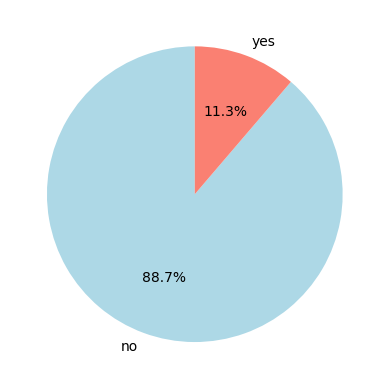

In [16]:
df["conversao"].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])

<Axes: xlabel='idade', ylabel='Count'>

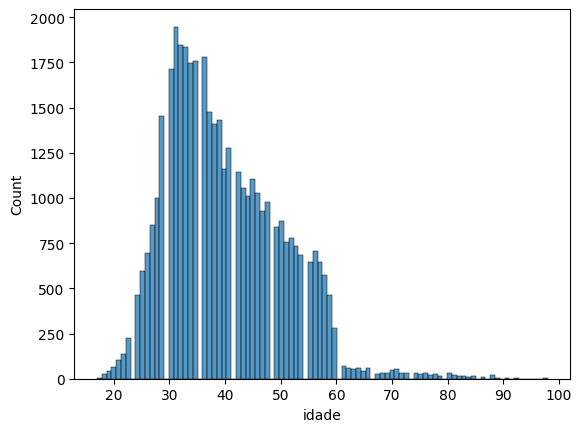

In [17]:
sns.histplot(df["idade"])

Text(0.5, 1.0, 'Distribuição das Profissões')

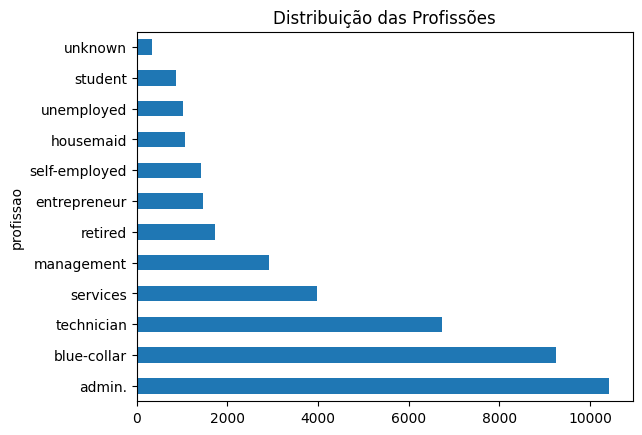

In [18]:
df["profissao"].value_counts().sort_values(ascending=False).plot(kind='barh').set_title("Distribuição das Profissões")

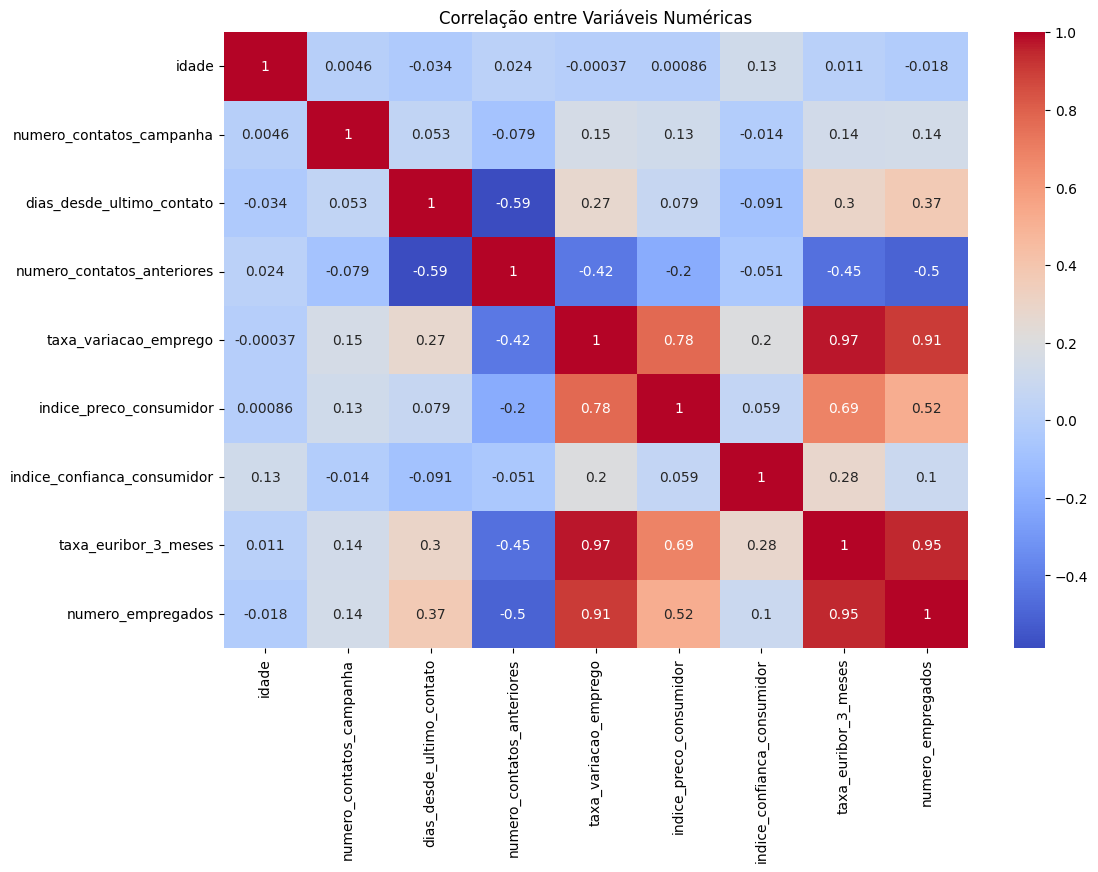

In [19]:
numericas = [
    'idade',
    'numero_contatos_campanha',
    'dias_desde_ultimo_contato',
    'numero_contatos_anteriores',
    'taxa_variacao_emprego',
    'indice_preco_consumidor',
    'indice_confianca_consumidor',
    'taxa_euribor_3_meses',
    'numero_empregados'
]
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df[numericas].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlação entre Variáveis Numéricas")
plt.show()

In [20]:
df.numero_contatos_campanha.max()

np.int64(56)

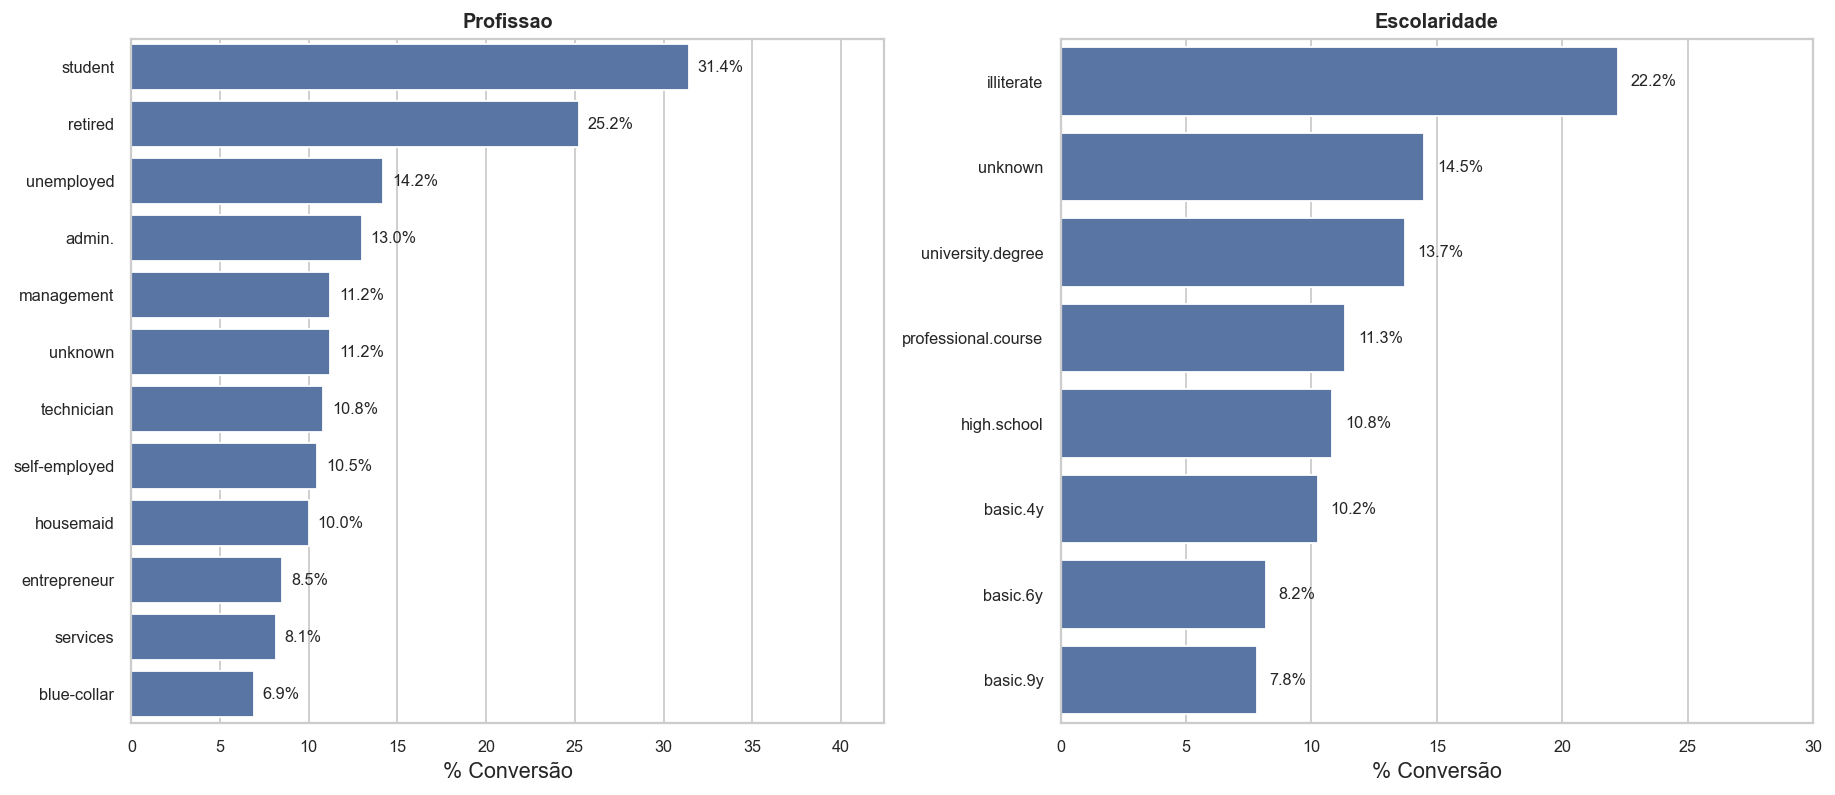

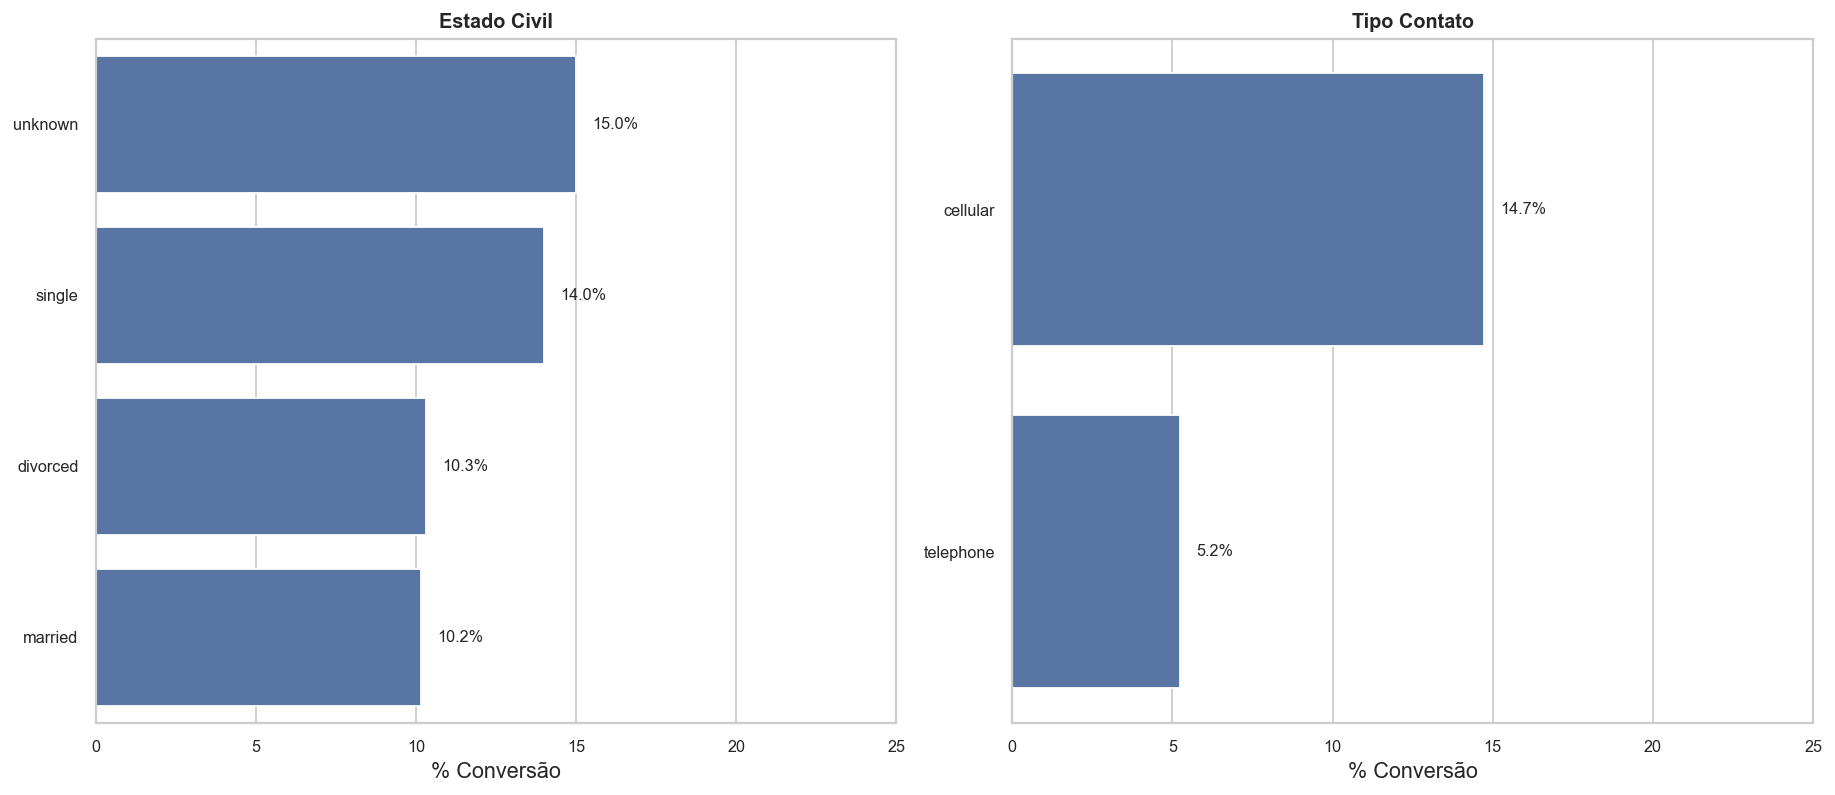

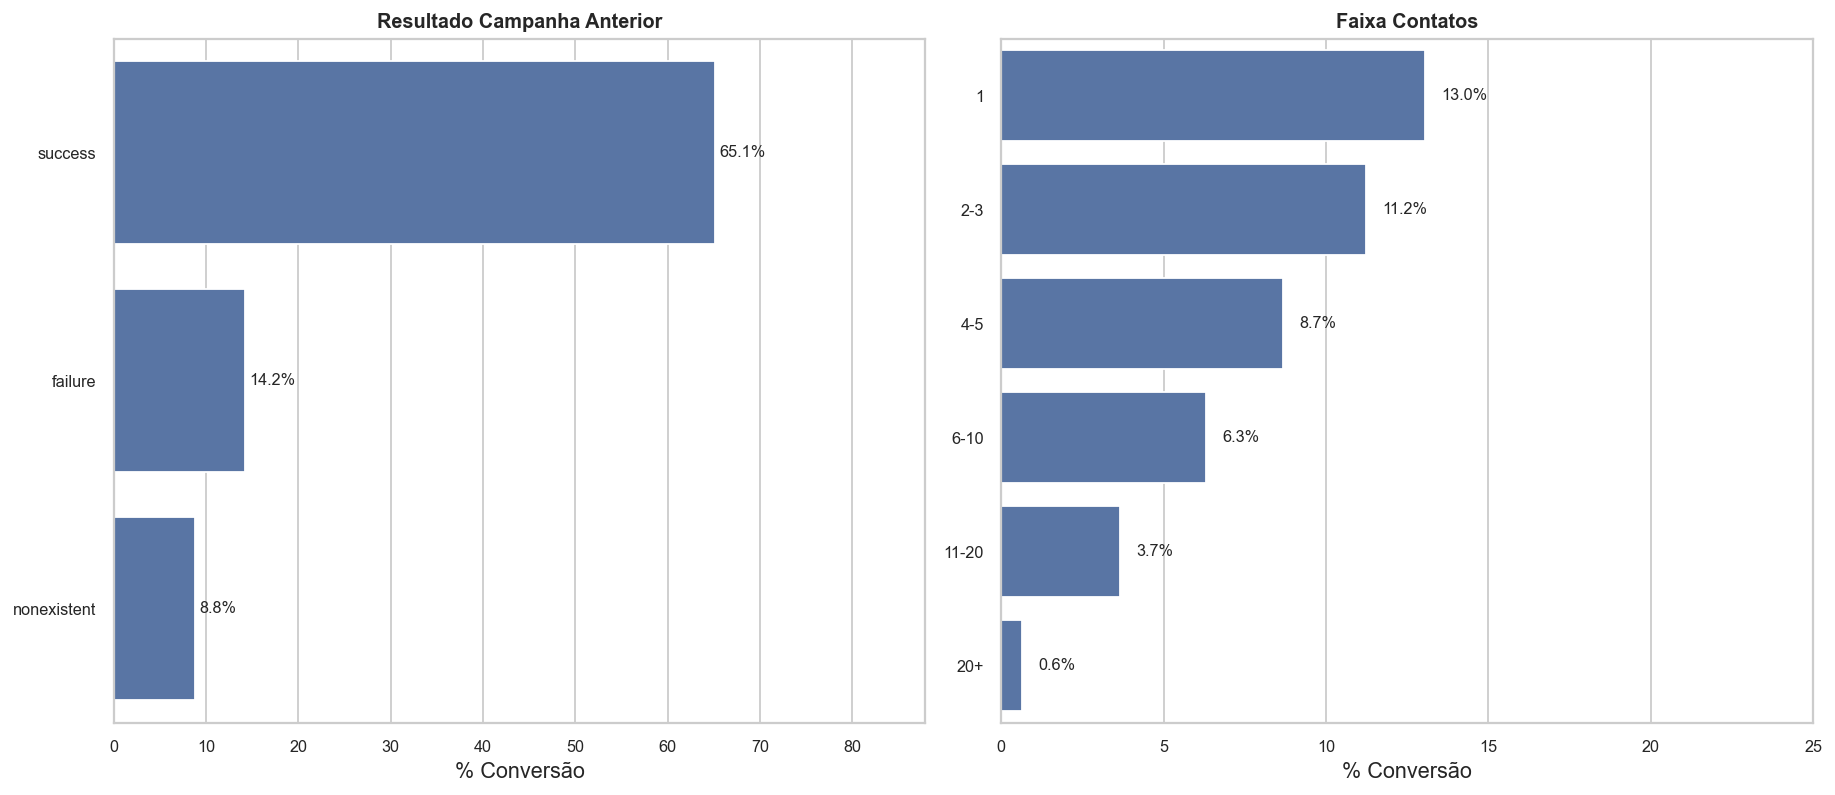

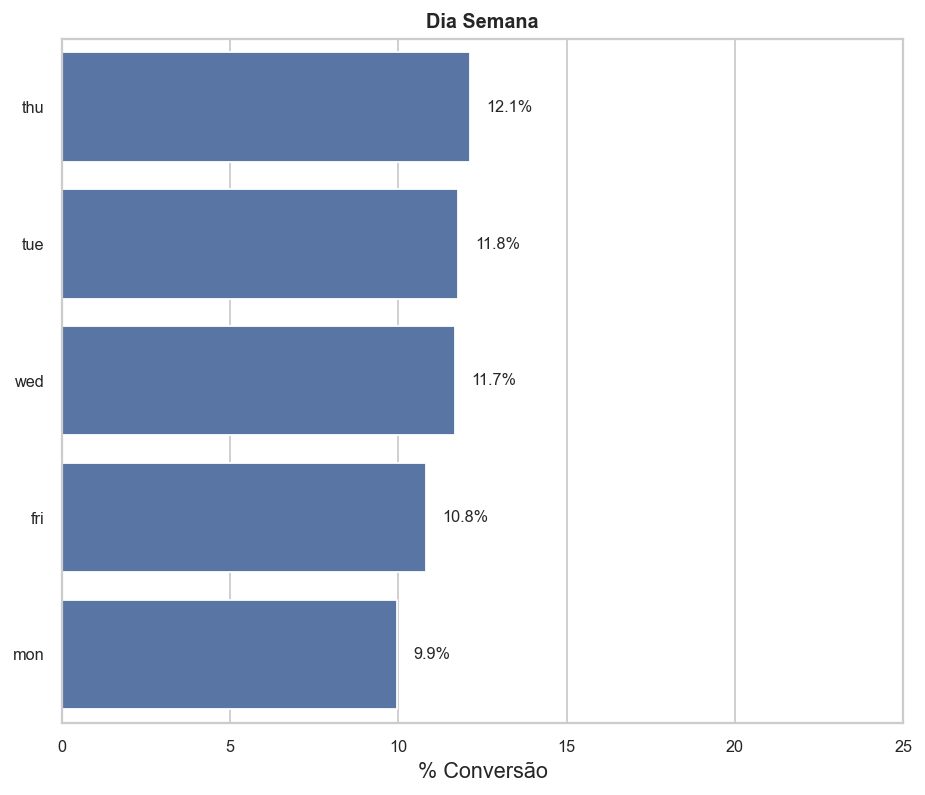

In [21]:
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130

variaveis = [
    "profissao",
    "escolaridade",
    "estado_civil",
    "tipo_contato",
    "resultado_campanha_anterior",
    "faixa_contatos",
    "dia_semana"
]

def plot_taxa_conversao_grid(df, variaveis, target="conversao", positive_class="yes", graficos_por_figura=2):
    for inicio in range(0, len(variaveis), graficos_por_figura):
        grupo = variaveis[inicio:inicio + graficos_por_figura]

        fig, axes = plt.subplots(
            1,
            len(grupo),
            figsize=(7 * len(grupo), 6),
            constrained_layout=True
        )

        if len(grupo) == 1:
            axes = [axes]

        for ax, coluna in zip(axes, grupo):
            taxa = (
                pd.crosstab(
                    df[coluna],
                    df[target],
                    normalize="index"
                )[positive_class]
                .sort_values(ascending=False)
                .reset_index(name="taxa_conversao")
            )

            taxa["taxa_conversao"] *= 100

            sns.barplot(
                data=taxa,
                y=coluna,
                x="taxa_conversao",
                ax=ax
            )
            

            for i, valor in enumerate(taxa["taxa_conversao"]):
                ax.text(
                    valor + 0.5,
                    i,
                    f"{valor:.1f}%",
                    va="center",
                    fontsize=9
                )

            ax.set_title(
                coluna.replace("_", " ").title(),
                fontsize=11,
                fontweight="bold"
            )
            ax.set_xlabel("% Conversão")
            ax.set_ylabel("")
            ax.tick_params(axis="y", labelsize=9)
            ax.tick_params(axis="x", labelsize=9)
            ax.set_xlim(0, max(25, max(taxa["taxa_conversao"]) * 1.35))

        plt.show()

plot_taxa_conversao_grid(df, variaveis)

In [ ]:
from pathlib import Path

output_path = Path(__file__).resolve().parents[1] / "data" / "processed" / "modeling_table.csv" \
    if "__file__" in dir() else Path("../data/processed/modeling_table.csv")

output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)
print(f"Salvo em: {output_path.resolve()}")